# Notebook 05 — Main Model: Fine-tuning IndoBERT Multi-Seed (ACSC)

Fase CRISP-DM : Modeling (model utama)
Input : dataset_split.csv (dari NB04 — test set identik dengan baseline)
Output : training_history_multiseed.json, predictions_indobert_revisi.csv, eval_indobert_revisi.csv, best_model_indobert_revisi.pt, confusion_indobert_revisi.png, f1_per_aspek_indobert.csv

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Konfigurasi

In [7]:
# from google.colab import drive; drive.mount('/content/drive')
# !pip install -q transformers==4.* torch --upgrade
import pandas as pd, numpy as np, torch, random, json
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

BASE       = "/content/drive/MyDrive/TA_ACSC_EWA"
SPLIT_PATH = f"{BASE}/05_modeling/dataset_split.csv"
OUT_DIR    = f"{BASE}/05_modeling/indobert"

MODEL="indobenchmark/indobert-base-p1"
MAXLEN=128; BATCH=16; EPOCHS=4; LR=2e-5; WD=0.01
SEEDS=[42,123,2024,7,99]
LABEL2ID={'positif':0,'negatif':1,'netral':2}; ID2LABEL={v:k for k,v in LABEL2ID.items()}
device='cuda' if torch.cuda.is_available() else 'cpu'
print("Device:",device)
tok=BertTokenizer.from_pretrained(MODEL)


Device: cuda


## 2. Muat Split dari NB04

Split dimuat dari dataset_split.csv sehingga test set identik dengan baseline, lalu anti-leakage diverifikasi ulang.

In [8]:
df=pd.read_csv(SPLIT_PATH)
train=df[df['split']=='train'].reset_index(drop=True)
val  =df[df['split']=='val'].reset_index(drop=True)
test =df[df['split']=='test'].reset_index(drop=True)
print(f"train {len(train)} | val {len(val)} | test {len(test)}")
# Verifikasi ulang anti-leakage
assert len(set(train['review_id'])&set(test['review_id']))==0, "leakage review_id!"
assert len(set(train['review_text_clean'])&set(test['review_text_clean']))==0, "leakage teks!"
print("Anti-leakage OK (0 overlap review_id & teks)")


train 1627 | val 185 | test 454
Anti-leakage OK (0 overlap review_id & teks)


## 3. Dataset & Tokenisasi (Sentence-Pair)

Input berformat pasangan: [CLS] teks_ulasan [SEP] aspek [SEP]. Tokenizer menghasilkan input_ids, attention_mask, dan token_type_ids (penanda segmen teks vs aspek), max_length 128. Class weight dihitung dari data train untuk menangani ketidakseimbangan kelas.

In [9]:
class ACSCDataset(Dataset):
    def __init__(self, d):
        self.t=d['review_text_clean'].astype(str).tolist()
        self.a=d['aspect_category'].astype(str).tolist()
        self.y=[LABEL2ID[x] for x in d['sentiment']]
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        e=tok(self.t[i], self.a[i].lower(), truncation=True, max_length=MAXLEN,
              padding='max_length', return_token_type_ids=True, return_tensors='pt')
        item={k:v.squeeze(0) for k,v in e.items()}
        item['labels']=torch.tensor(self.y[i])
        return item

val_dl =DataLoader(ACSCDataset(val),  batch_size=32)
test_dl=DataLoader(ACSCDataset(test), batch_size=32)

# Class weight (imbalance handling) dari train
cw=torch.tensor(compute_class_weight('balanced', classes=np.array([0,1,2]),
     y=[LABEL2ID[x] for x in train['sentiment']]), dtype=torch.float).to(device)
print("Class weights (pos,neg,net):", cw.cpu().numpy().round(3))


Class weights (pos,neg,net): [0.647 0.784 5.591]


## 4. Fine-tuning Multi-Seed

Untuk setiap seed: latih 4 epoch, evaluasi validasi tiap akhir epoch, simpan checkpoint saat Val Weighted-F1 terbaik, lalu evaluasi checkpoint terbaik satu kali pada test. Weighted-F1 dipakai sebagai kriteria checkpoint karena validasi hanya memuat 12 sampel netral sehingga Macro-F1 validasi terlalu sensitif untuk pengambilan keputusan.

In [10]:
def set_seed(sd):
    random.seed(sd); np.random.seed(sd); torch.manual_seed(sd); torch.cuda.manual_seed_all(sd)

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); P=[]; Y=[]
    for b in loader:
        b={k:v.to(device) for k,v in b.items()}
        logits=model(input_ids=b['input_ids'], attention_mask=b['attention_mask'],
                     token_type_ids=b['token_type_ids']).logits
        P+=logits.argmax(-1).cpu().tolist(); Y+=b['labels'].cpu().tolist()
    return f1_score(Y,P,average='macro'), f1_score(Y,P,average='weighted'), P, Y

hist={e:[] for e in range(1,EPOCHS+1)}
test_macro_per_seed=[]
best_overall={'wf1':-1,'state':None,'seed':None,'pred':None,'y':None}

for sd in SEEDS:
    print(f"\n{'='*50}\nSEED {sd}\n{'='*50}")
    set_seed(sd)
    model=BertForSequenceClassification.from_pretrained(MODEL,num_labels=3).to(device)
    tr_dl=DataLoader(ACSCDataset(train), batch_size=BATCH, shuffle=True)
    opt=torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched=get_linear_schedule_with_warmup(opt, 0, len(tr_dl)*EPOCHS)
    lossf=torch.nn.CrossEntropyLoss(weight=cw)
    best_wf1=-1; best_state=None
    for ep in range(1,EPOCHS+1):
        model.train()
        for b in tr_dl:
            b={k:v.to(device) for k,v in b.items()}
            opt.zero_grad()
            logits=model(input_ids=b['input_ids'], attention_mask=b['attention_mask'],
                         token_type_ids=b['token_type_ids']).logits
            loss=lossf(logits, b['labels']); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); sched.step()
        vmf1,vwf1,_,_=evaluate(model,val_dl); hist[ep].append(vmf1)
        print(f"  epoch {ep}: val_macroF1={vmf1:.4f} val_wtF1={vwf1:.4f}")
        if vwf1>best_wf1:
            best_wf1=vwf1; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}
    # test dgn checkpoint terbaik seed ini
    model.load_state_dict(best_state)
    tmf1,twf1,tp,ty=evaluate(model,test_dl); test_macro_per_seed.append(tmf1)
    print(f"  -> TEST macroF1={tmf1:.4f} wtF1={twf1:.4f}")
    if best_wf1>best_overall['wf1']:
        best_overall.update({'wf1':best_wf1,'state':best_state,'seed':sd,'pred':tp,'y':ty})



SEED 42


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  epoch 1: val_macroF1=0.9273 val_wtF1=0.9350
  epoch 2: val_macroF1=0.9148 val_wtF1=0.9295
  epoch 3: val_macroF1=0.8910 val_wtF1=0.9283
  epoch 4: val_macroF1=0.9271 val_wtF1=0.9348
  -> TEST macroF1=0.8493 wtF1=0.8931

SEED 99


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1: val_macroF1=0.9081 val_wtF1=0.9292
  epoch 2: val_macroF1=0.9112 val_wtF1=0.9128
  epoch 3: val_macroF1=0.9041 val_wtF1=0.9236
  epoch 4: val_macroF1=0.9042 val_wtF1=0.9238
  -> TEST macroF1=0.8825 wtF1=0.9010


## 5. Ringkasan Multi-Seed (mean ± std) (mean dan simpangan baku)

In [11]:
print("="*55); print("STABILITAS PER EPOCH (5 seed)"); print("="*55)
summary={}
for ep in range(1,EPOCHS+1):
    a=np.array(hist[ep]); summary[ep]={'mean':float(a.mean()),'std':float(a.std())}
    print(f"  Val Macro-F1 epoch {ep}: {a.mean():.4f} ± {a.std():.4f}")
t=np.array(test_macro_per_seed)
print(f"\n  Test Macro-F1 (best ckpt/seed): {t.mean():.4f} ± {t.std():.4f}")
best_ep=max(range(1,EPOCHS+1), key=lambda e: summary[e]['mean'])
print(f"  Epoch terbaik rata-rata       : epoch {best_ep}")
print("\nKESIMPULAN: jika epoch {} punya mean tertinggi & std kecil,".format(best_ep))
print("pemilihan epoch tsb VALID (bukan kebetulan satu run).")

json.dump({'per_epoch':summary,'test_per_seed':test_macro_per_seed,'seeds':SEEDS},
          open(f"{OUT_DIR}/training_history_multiseed.json","w"), indent=2)


STABILITAS PER EPOCH (5 seed)
  Val Macro-F1 epoch 1: 0.9137 ± 0.0083
  Val Macro-F1 epoch 2: 0.9082 ± 0.0159
  Val Macro-F1 epoch 3: 0.9089 ± 0.0191
  Val Macro-F1 epoch 4: 0.9141 ± 0.0107

  Test Macro-F1 (best ckpt/seed): 0.8762 ± 0.0137
  Epoch terbaik rata-rata       : epoch 4

KESIMPULAN: jika epoch 4 punya mean tertinggi & std kecil,
pemilihan epoch tsb VALID (bukan kebetulan satu run).


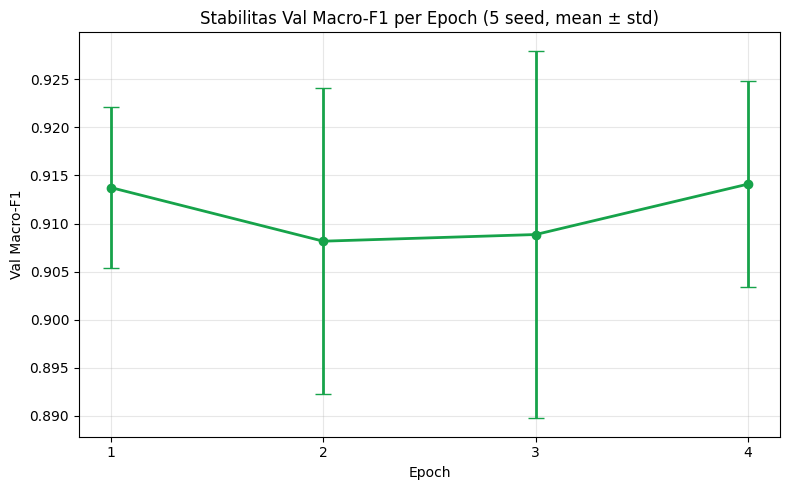

In [ ]:
# Visualisasi stabilitas: mean ± std per epoch
eps=list(range(1,EPOCHS+1)); means=[summary[e]['mean'] for e in eps]; stds=[summary[e]['std'] for e in eps]
plt.figure(figsize=(8,5))
plt.errorbar(eps,means,yerr=stds,marker='o',capsize=6,lw=2,color='#16a34a')
plt.xticks(eps); plt.xlabel('Epoch'); plt.ylabel('Val Macro-F1')
plt.title('Stabilitas Val Macro-F1 per Epoch (5 seed, mean ± std)')
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/stabilitas_multiseed.png",dpi=150,bbox_inches='tight'); plt.show()


## 6. Evaluasi Model Terbaik pada Test

In [ ]:
pred=best_overall['pred']; y=best_overall['y']
labels_id=[0,1,2]; labels_nm=['positif','negatif','netral']
macro=f1_score(y,pred,average='macro'); wt=f1_score(y,pred,average='weighted')
print(f"Model terbaik (seed {best_overall['seed']})")
print(f"Test Macro-F1={macro:.4f} | Weighted-F1={wt:.4f}\n")
print(classification_report(y,pred,target_names=labels_nm,digits=4))

# Simpan prediksi (untuk audit leakage & per-aspek)
test_out=test.copy()
test_out['y_pred']=[ID2LABEL[p] for p in pred]
test_out['correct']=(test_out['sentiment']==test_out['y_pred'])
test_out.to_csv(f"{OUT_DIR}/predictions_indobert_revisi.csv",index=False)
pd.DataFrame([{'model':'IndoBERT','macro_f1':macro,'weighted_f1':wt,'best_seed':best_overall['seed'],
               'n_train':len(train),'n_val':len(val),'n_test':len(test)}]).to_csv(f"{OUT_DIR}/eval_indobert_revisi.csv",index=False)
torch.save(best_overall['state'], f"{OUT_DIR}/best_model_indobert_revisi.pt")


Model terbaik (seed 123)
Test Macro-F1=0.8843 | Weighted-F1=0.9080

              precision    recall  f1-score   support

     positif     0.9489    0.9028    0.9253       247
     negatif     0.8711    0.9185    0.8942       184
      netral     0.8000    0.8696    0.8333        23

    accuracy                         0.9075       454
   macro avg     0.8734    0.8970    0.8843       454
weighted avg     0.9099    0.9075    0.9080       454



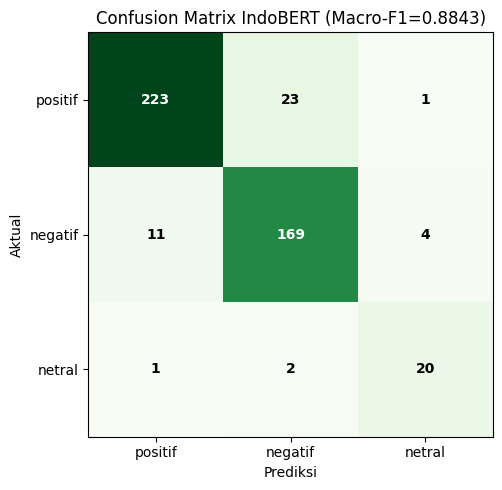

In [ ]:
cm=confusion_matrix(y,pred,labels=labels_id)
fig,ax=plt.subplots(figsize=(6,5)); ax.imshow(cm,cmap='Greens')
ax.set_xticks(range(3)); ax.set_yticks(range(3)); ax.set_xticklabels(labels_nm); ax.set_yticklabels(labels_nm)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual'); ax.set_title(f'Confusion Matrix IndoBERT (Macro-F1={macro:.4f})')
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black',fontweight='bold')
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_indobert_revisi.png",dpi=150,bbox_inches='tight'); plt.show()


## 7. Evaluasi Per-Aspek

Metrik agregat dapat menyembunyikan variasi antar aspek; F1 dihitung per kategori aspek dan disimpan untuk perbandingan dengan baseline.

In [ ]:
def f1_per_aspek(dfp):
    rows=[]
    for asp in dfp['aspect_category'].unique():
        d=dfp[dfp['aspect_category']==asp]
        f1s=[f1_score(d['sentiment'],d['y_pred'],average=None,labels=[c],zero_division=0)[0] for c in ['positif','negatif','netral']]
        rows.append({'Aspek':asp,'n_test':len(d),'Accuracy':round((d['sentiment']==d['y_pred']).mean(),3),'Macro-F1':round(np.mean(f1s),3)})
    return pd.DataFrame(rows).sort_values('n_test',ascending=False)
tbl=f1_per_aspek(test_out); print(tbl.to_string(index=False)); tbl.to_csv(f"{OUT_DIR}/f1_per_aspek_indobert.csv",index=False)


               Aspek  n_test  Accuracy  Macro-F1
Kemudahan Penggunaan     256     0.945     0.940
    Keandalan Sistem      83     0.928     0.694
 Kecepatan Pencairan      55     0.782     0.787
      Biaya/Potongan      42     0.810     0.800
    Customer Service      18     0.889     0.827


## 8. Verifikasi Leakage pada Prediksi

Pengecekan terakhir: tidak ada teks test yang muncul di train.

In [ ]:
train_txt=set(train['review_text_clean'])
bocor=test_out['review_text_clean'].isin(train_txt).sum()
print(f"Baris test yang teksnya muncul di train: {bocor} (harus 0)")
print("=> Semua metrik di atas dihitung pada data yang BENAR-BENAR bersih." if bocor==0 else "PERINGATAN: masih ada leakage!")


Baris test yang teksnya muncul di train: 0 (harus 0)
=> Semua metrik di atas dihitung pada data yang BENAR-BENAR bersih.


## Ringkasan

IndoBERT dilatih lima kali dengan seed berbeda; klaim utama adalah rata-rata dan simpangan baku Test Macro-F1 (0,8762 plus-minus 0,0137), dengan checkpoint terbaik dipilih dari validasi dan test disentuh sekali per seed. Evaluasi per kelas memakai checkpoint perwakilan (seed 123), dan evaluasi per aspek tersimpan untuk analisis perbandingan dengan baseline pada NB06.